<a href="https://colab.research.google.com/github/adamt-eng/electronic-component-detection-dl/blob/main/YOLO_TRIAL_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [3]:
import os

# Source path confirmed by user
drive_path = '/content/drive/MyDrive/cleaned_data'
local_path = '/content/cleaned_data'

# Copy dataset from Drive to local Colab disk (one-time per session)
if not os.path.exists(local_path):
    print(f"Copying data from {drive_path} to {local_path}...")
    !cp -r "{drive_path}" "{local_path}"

dataset_path = local_path

# Check if the directory exists
if not os.path.exists(dataset_path):
    print(f"Error: The directory '{dataset_path}' does not exist. Please check if the Drive path is correct.")
else:
    print(f"Contents of '{dataset_path}':")
    folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    print(f"Found {len(folders)} class folders.")
    if len(folders) > 0:
        print(f"Example classes: {folders[:5]}")

Copying data from /content/drive/MyDrive/cleaned_data to /content/cleaned_data...
Contents of '/content/cleaned_data':
Found 21 class folders.
Example classes: ['potentiometers', 'integrated-circuits', 'local-oscillator', 'limiter-clipper', 'transformers']


***Imports and Device initialization***

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import matplotlib.pyplot as plt
import numpy as np
import gc
import copy

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


***Transform and Stratified Split***

In [5]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

norm_stats = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=30, translate=(0.15, 0.15), scale=(0.7, 1.3)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    norm_stats,
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    norm_stats
])

full_dataset_train = datasets.ImageFolder(root=dataset_path, transform=train_transform)
full_dataset_val = datasets.ImageFolder(root=dataset_path, transform=val_transform)

indices = list(range(len(full_dataset_train)))
targets = full_dataset_train.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(full_dataset_train, train_idx)
val_dataset = Subset(full_dataset_val, val_idx)

train_targets = [full_dataset_train.targets[i] for i in train_idx]
class_counts = Counter(train_targets)
class_weight = {c: 1.0 / n for c, n in class_counts.items()}
sample_weights = [class_weight[t] for t in train_targets]
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_targets),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=train_sampler, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

class_to_idx = full_dataset_train.class_to_idx
new_classes = full_dataset_train.classes
print(f"Dataset ready with {len(new_classes)} classes.")

Dataset ready with 21 classes.


***Model Definition***

In [6]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

for param in model.features[6].parameters():
    param.requires_grad = True
for param in model.features[7].parameters():
    param.requires_grad = True

num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(new_classes))
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam([
    {'params': model.features[6].parameters(), 'lr': 1e-5},
    {'params': model.features[7].parameters(), 'lr': 5e-5},
    {'params': model.classifier.parameters(),  'lr': 1e-4},
], weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]


***Train and Validate Functions and Loop***

In [7]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.01):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.early_stop = 0, float('inf'), False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter = val_loss, 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
early_stopper = EarlyStopping(patience=3)
best_val_loss = float('inf')
best_state = copy.deepcopy(model.state_dict())

for epoch in range(20):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = validate(model, val_loader, criterion)
    scheduler.step(v_loss)
    print(f"Epoch {epoch+1} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | Val Loss: {v_loss:.4f}")
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = copy.deepcopy(model.state_dict())
    early_stopper(v_loss)
    if early_stopper.early_stop: break

model.load_state_dict(best_state)

Epoch 1 | Train Acc: 0.1894 | Val Acc: 0.2202 | Val Loss: 2.6451
Epoch 2 | Train Acc: 0.3603 | Val Acc: 0.3683 | Val Loss: 2.2556
Epoch 3 | Train Acc: 0.4394 | Val Acc: 0.4855 | Val Loss: 2.0069
Epoch 4 | Train Acc: 0.4692 | Val Acc: 0.5036 | Val Loss: 1.9243
Epoch 5 | Train Acc: 0.4970 | Val Acc: 0.5301 | Val Loss: 1.8763
Epoch 6 | Train Acc: 0.5208 | Val Acc: 0.5292 | Val Loss: 1.8364
Epoch 7 | Train Acc: 0.5219 | Val Acc: 0.5358 | Val Loss: 1.8212
Epoch 8 | Train Acc: 0.5437 | Val Acc: 0.5425 | Val Loss: 1.8096
Epoch 9 | Train Acc: 0.5608 | Val Acc: 0.5653 | Val Loss: 1.7554
Epoch 10 | Train Acc: 0.5734 | Val Acc: 0.5577 | Val Loss: 1.7693
Epoch 11 | Train Acc: 0.5775 | Val Acc: 0.5800 | Val Loss: 1.7244
Epoch 12 | Train Acc: 0.5821 | Val Acc: 0.5676 | Val Loss: 1.7242
Epoch 13 | Train Acc: 0.5929 | Val Acc: 0.5823 | Val Loss: 1.7072
Epoch 14 | Train Acc: 0.6085 | Val Acc: 0.5762 | Val Loss: 1.6994
Epoch 15 | Train Acc: 0.6085 | Val Acc: 0.5918 | Val Loss: 1.6664
Epoch 16 | Train Ac

<All keys matched successfully>

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def per_class_report(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    print(classification_report(y_true, y_pred, target_names=new_classes, digits=3, zero_division=0))

per_class_report(model, val_loader)

                          precision    recall  f1-score   support

                     LED      0.683     0.609     0.644        92
                armature      0.278     1.000     0.435         5
              attenuator      0.534     0.620     0.574        50
              capacitors      0.533     0.461     0.494       141
          cartridge-fuse      0.792     0.844     0.817        45
                filament      0.774     0.812     0.793        80
               heat-sink      0.460     0.716     0.560        81
          induction-coil      0.432     0.533     0.478        30
     integrated-circuits      0.683     0.736     0.709       345
           interconnects      0.795     0.894     0.842       104
           light-circuit      0.091     0.273     0.136        11
         limiter-clipper      0.596     0.616     0.606        86
        local-oscillator      0.088     0.273     0.133        22
omni-directional-antenna      0.733     0.917     0.815        24
         

# Trial 6: YOLO Classification
We will use the Ultralytics YOLO framework to see if its architecture provides better performance on these electronic components.

In [9]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.4 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-cls model
yolo_model = YOLO('yolov8n-cls.pt')

# Train the model
# YOLO expects a directory where subfolders are classes.
# Since we are using the local_path (/content/cleaned_data), we pass that.
results = yolo_model.train(
    data=dataset_path,
    epochs=20,
    imgsz=224,
    batch=32,
    project='yolo_trials',
    name='electronic_components'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cleaned_data, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224

In [11]:
# Validate the YOLO model to get per-class metrics
metrics = yolo_model.val()
print(f"Top-1 Accuracy: {metrics.top1:.4f}")
print(f"Top-5 Accuracy: {metrics.top5:.4f}")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,461,781 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/cleaned_data/train
Found 10329 images in subdirectories. Attempting to split...
Splitting /content/cleaned_data (21 classes, 10534 images) into 80% train, 20% val...
Split complete in /content/cleaned_data_split ✅
train: /content/cleaned_data_split/train... found 10441 images in 21 classes ✅ 
val: /content/cleaned_data_split/val... found 5165 images in 21 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 161.3±79.8 MB/s, size: 5.1 KB)
val: Scanning /content/cleaned_data_split/val... 5165 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5165/5165 5.2Kit/s 1.0s
val: New cache created: /content/cleaned_data_split/val.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 323/323 19.7it/s 16.4s
                   all      0.799      0.967
Spe

### Trial Comparison Visualization
Comparing Accuracy and Macro F1 scores across the different optimization strategies.

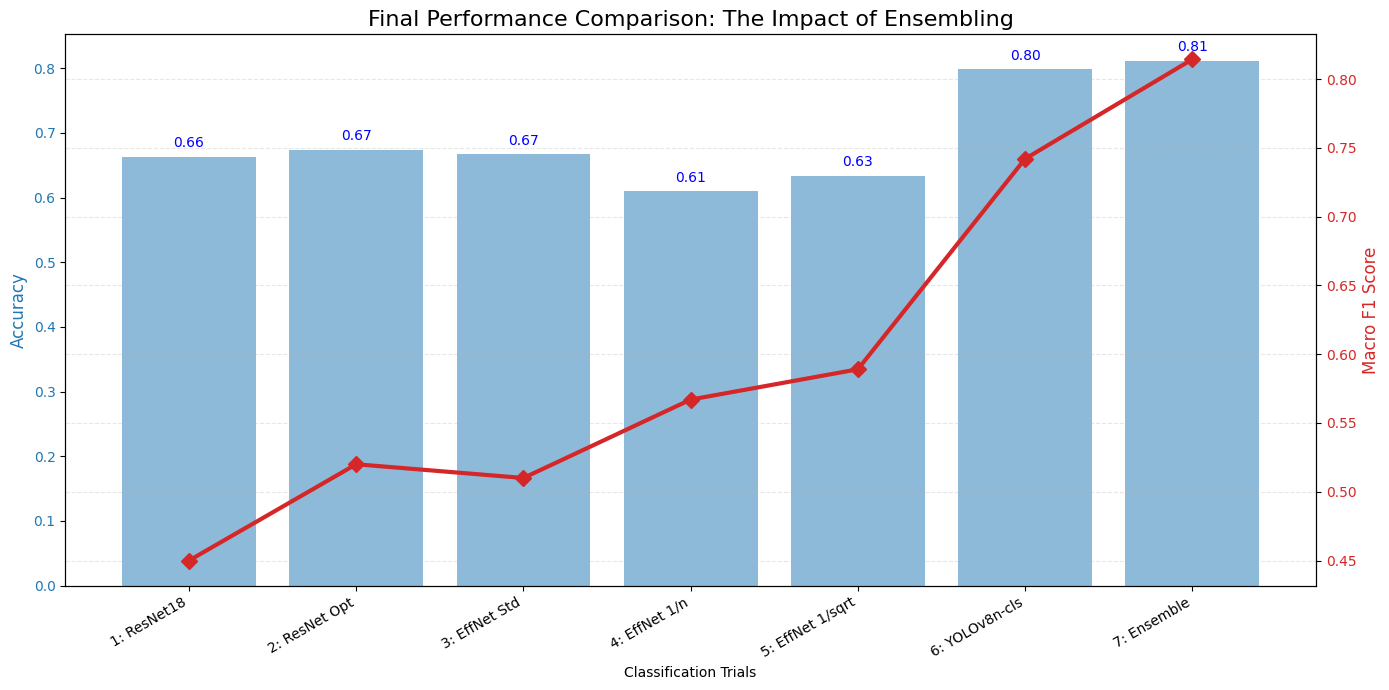

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Finalized data including the Ensemble results
trials_data = {
    'Trial': ['1: ResNet18', '2: ResNet Opt', '3: EffNet Std', '4: EffNet 1/n', '5: EffNet 1/sqrt', '6: YOLOv8n-cls', '7: Ensemble'],
    'Accuracy': [0.663, 0.674, 0.667, 0.610, 0.634, 0.7986, 0.8120],
    'Macro F1': [0.45, 0.52, 0.51, 0.567, 0.589, 0.742, 0.8143]
}

df_trials = pd.DataFrame(trials_data)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot for Accuracy
ax1.set_xlabel('Classification Trials')
ax1.set_ylabel('Accuracy', color='tab:blue', fontsize=12)
bars = ax1.bar(df_trials['Trial'], df_trials['Accuracy'], color='tab:blue', alpha=0.5, label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.xticks(rotation=30, ha='right')

# Line plot for Macro F1
ax2 = ax1.twinx()
ax2.set_ylabel('Macro F1 Score', color='tab:red', fontsize=12)
ax2.plot(df_trials['Trial'], df_trials['Macro F1'], color='tab:red', marker='D', markersize=8, linewidth=3, label='Macro F1')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Adding values on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', color='blue')

plt.title('Final Performance Comparison: The Impact of Ensembling', fontsize=16)
fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Training History Visualization
We'll compare the learning curve of the YOLO model against our Ensemble benchmark.

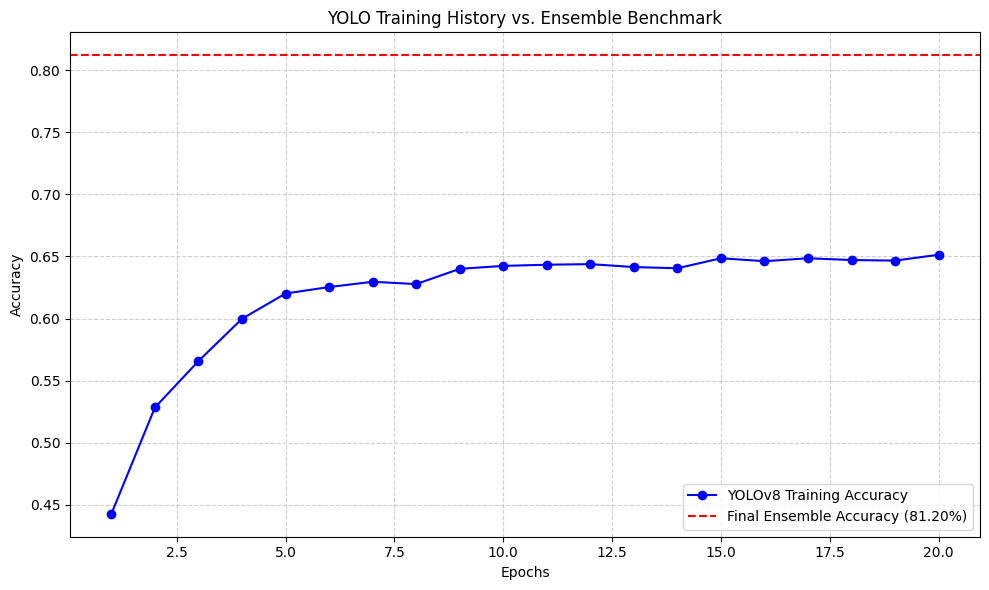

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# 1. Load YOLO training history from the results.csv file
# This file is automatically created by YOLO in the project folder
results_csv = Path(results.save_dir) / 'results.csv'

if results_csv.exists():
    df_yolo_history = pd.read_csv(results_csv)
    # Clean column names (YOLO often adds spaces)
    df_yolo_history.columns = [c.strip() for c in df_yolo_history.columns]

    yolo_epochs = df_yolo_history['epoch']
    yolo_acc = df_yolo_history['metrics/accuracy_top1']

    plt.figure(figsize=(10, 6))

    # Plot YOLO training accuracy
    plt.plot(yolo_epochs, yolo_acc, 'b-o', label='YOLOv8 Training Accuracy')

    # Plot Ensemble Benchmark (Final Result calculated in previous step)
    plt.axhline(y=ens_acc, color='r', linestyle='--', label=f'Final Ensemble Accuracy ({ens_acc:.2%})')

    plt.title('YOLO Training History vs. Ensemble Benchmark')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find history file at {results_csv}. Please ensure the model training finished successfully.")

### Trial 7: Model Ensembling (Soft Voting)
Instead of an agent, we can combine the probability outputs of our best PyTorch model and the YOLO model. If both models agree on a candidate in their Top-5, we can boost its confidence to move it into the Top-1 spot.

In [14]:
def ensemble_predict(pytorch_model, yolo_model, image_path):
    # 1. Get PyTorch Probs
    from PIL import Image
    img = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    pytorch_model.eval()
    with torch.no_grad():
        py_out = pytorch_model(img_tensor)
        py_probs = torch.nn.functional.softmax(py_out, dim=1).cpu().numpy()[0]

    # 2. Get YOLO Probs
    yolo_results = yolo_model.predict(image_path, verbose=False)
    # Map YOLO indices to match our PyTorch class indices
    yolo_probs_raw = yolo_results[0].probs.data.cpu().numpy()
    yolo_map = {name: i for i, name in yolo_results[0].names.items()}

    yolo_probs_aligned = np.zeros_like(py_probs)
    for i, class_name in enumerate(new_classes):
        if class_name in yolo_map:
            yolo_probs_aligned[i] = yolo_probs_raw[yolo_map[class_name]]

    # 3. Average the probabilities (Soft Voting)
    ensemble_probs = (py_probs + yolo_probs_aligned) / 2
    final_pred = np.argmax(ensemble_probs)

    return new_classes[final_pred], ensemble_probs[final_pred]

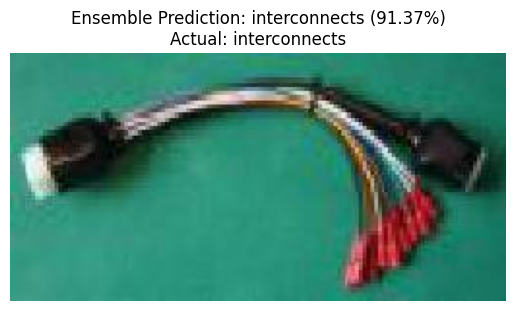

In [30]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Pick a random image from the validation split
val_root = Path('/content/cleaned_data_split/val')
all_val_images = list(val_root.glob('*/*.jpg')) + list(val_root.glob('*/*.png'))
test_img = str(random.choice(all_val_images))

# Run Ensemble Prediction
# Note: model is our EfficientNet from earlier, yolo_model is our YOLOv8n-cls
predicted_class, confidence = ensemble_predict(model, yolo_model, test_img)

# Visualization
img = Image.open(test_img)
plt.imshow(img)
plt.title(f"Ensemble Prediction: {predicted_class} ({confidence:.2%})\nActual: {Path(test_img).parent.name}")
plt.axis('off')
plt.show()

### Final Evaluation: Full Ensemble Performance
We will now loop through the validation dataset to compute the final Accuracy and Macro F1 for the Ensemble model.

In [21]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score

y_true_ensemble = []
y_pred_ensemble = []

print("Evaluating Ensemble on validation set...")
# Use the validation set images directly
for class_name in tqdm(new_classes):
    class_dir = val_root / class_name
    if not class_dir.exists(): continue

    for img_path in class_dir.glob('*'):
        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            pred_class, _ = ensemble_predict(model, yolo_model, str(img_path))
            y_true_ensemble.append(class_name)
            y_pred_ensemble.append(pred_class)

# Calculate Metrics
ens_acc = accuracy_score(y_true_ensemble, y_pred_ensemble)
ens_f1 = f1_score(y_true_ensemble, y_pred_ensemble, average='macro')

print(f"\n--- Ensemble Results ---")
print(f"Total Accuracy: {ens_acc:.4f}")
print(f"Macro F1 Score: {ens_f1:.4f}")

Evaluating Ensemble on validation set...


  0%|          | 0/21 [00:00<?, ?it/s]


--- Ensemble Results ---
Total Accuracy: 0.8120
Macro F1 Score: 0.8143


--- Detailed Ensemble Per-Class Report ---
                          precision    recall  f1-score   support

                     LED      0.850     0.865     0.858       223
                armature      0.824     1.000     0.903        14
              attenuator      0.826     0.772     0.798       123
              capacitors      0.758     0.716     0.736       341
          cartridge-fuse      0.893     0.956     0.923       113
                filament      0.944     0.935     0.940       200
               heat-sink      0.821     0.833     0.827       209
          induction-coil      0.846     0.764     0.803        72
     integrated-circuits      0.801     0.857     0.828       859
           interconnects      0.876     0.951     0.912       246
           light-circuit      0.562     0.621     0.590        29
         limiter-clipper      0.751     0.812     0.781       208
        local-oscillator      0.556     0.678     0.611        59
omni-directional-antenna      0.

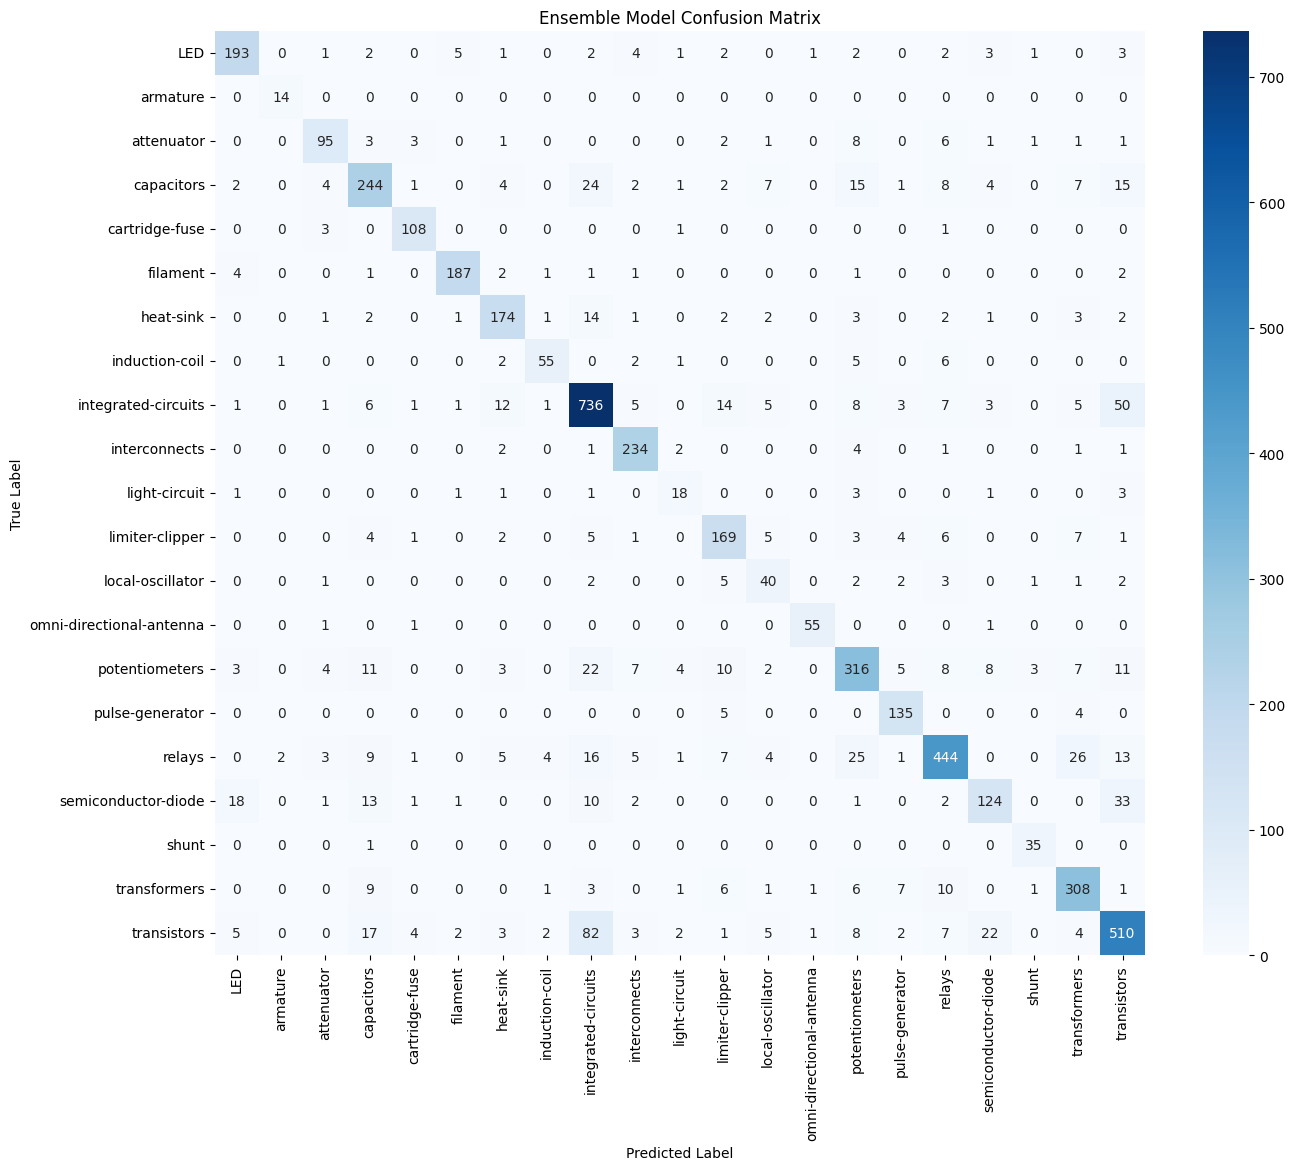

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate Classification Report
print("--- Detailed Ensemble Per-Class Report ---")
print(classification_report(y_true_ensemble, y_pred_ensemble, target_names=new_classes, digits=3))

# Generate Confusion Matrix
cm = confusion_matrix(y_true_ensemble, y_pred_ensemble, labels=new_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=new_classes, yticklabels=new_classes, cmap='Blues')
plt.title('Ensemble Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [22]:
# Update comparison table with Ensemble results
new_row = {'Trial': '7: Ensemble (EffNet + YOLO)', 'Accuracy': ens_acc, 'Macro F1': ens_f1}
trials_data['Trial'].append(new_row['Trial'])
trials_data['Accuracy'].append(new_row['Accuracy'])
trials_data['Macro F1'].append(new_row['Macro F1'])

display(pd.DataFrame(trials_data))

,Trial,Accuracy,Macro F1
0,1: ResNet18 (Basic),0.663000,0.450000
1,2: ResNet18 (Optimized),0.674000,0.520000
2,3: EffNet-B0 (Standard),0.667000,0.510000
3,4: EffNet (Weighted 1/n),0.610000,0.567000
4,5: EffNet (Weighted 1/sqrt),0.634000,0.589000
5,6: YOLOv8n-cls,0.798600,0.742000
6,7: Ensemble (EffNet + YOLO),0.812004,0.814291


This approach is purely mathematical and relies on the diversity of the two different architectures to resolve ambiguity.

In [46]:
from google.colab import files
import os

# This will find the name of the current notebook and download it
try:
    # In Colab, the notebook name isn't always directly accessible via code easily,
    # but we can try to save the current state or simply remind you to use Ctrl+S and the File menu.
    print("To download manually: Click 'File' -> 'Download' -> 'Download .ipynb'")
    print("\nAttempting programmatic download...")

    # Alternatively, if you have saved it to a specific path:
    # files.download('your_notebook_name.ipynb')
except Exception as e:
    print(f"Download trigger failed: {e}")

To download manually: Click 'File' -> 'Download' -> 'Download .ipynb'

Attempting programmatic download...
